# AG-HYPOPT · Trial 05

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Four trials recorded; best is trial 02 (0.0246). Trial 01 (lr_mu 10.09, sigma_ref 10.25, gamma_anneal 0.10) 0.0981, mu-limited. Trial 02 (lr_mu 25.36, sigma_ref 6.84, lr_gamma 0.44, gamma_anneal 0.20) 0.0246: high lr_mu cut mu rel RMSE to 17.5%. Trial 03 (lr_mu 23.05, sigma_ref 9.37, lr_gamma 0.79, gamma_anneal 0.22) 0.0477: gamma flat at 13.7%, mu back to 27.7%. Trial 04 (lr_mu 29.41, sigma_ref 6.62, lr_gamma 0.61, gamma_anneal 0.71) 0.0262: mu unchanged at 17.2% (lr_mu saturated), gamma slipped to 15.1%. Pattern: mu is set by lr_mu (~25 optimal) and sigma_ref (low ~6-7 good), gamma is insensitive to lr_gamma but hurt by high gamma_anneal (0.71), and the residual error sits at low signal (Trans05, mu -28% to -38%). Last uniform slot (4/5 done).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_05'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (4/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.6037521928090351, "lr_gamma": 0.846352631789195, "lr_mu": 17.88313902605355, "sigma_ref": 10.716027601762832}
 2 |      - | {"gamma_anneal": 0.04044802678624232, "lr_gamma": 0.5066951046284146, "lr_mu": 15.211830135499966, "sigma_ref": 5.905503878048903}
 3 |      - | {"gamma_anneal": 0.03656828304537604, "lr_gamma": 0.9993408920520572, "lr_mu": 21.309227789699694, "sigma_ref": 9.69020403339648}
 4 |      - | {"gamma_anneal": 0.3262106641688565, "lr_gamma": 0.9793489546074043, "lr_mu": 27.44194020271372, "sigma_ref": 21.88462075217482}
 5 |      - | {"gamma_anneal": 0.2943034982510836, "lr_gamma": 0.5944184149853942, "lr_mu": 21.91723379577665, "sigma_ref": 6.216054259161121}
 6 |      - | {"gamma_anneal": 0.4166970876905426, "lr_gamma": 0.4171612836240812, "lr_mu": 26.991279333373054, "sigma_ref": 6.284288746243821}
 7 |      - | {"gamma_anneal": 0.5093861497660237, "lr_gamma": 0.8960708018620027, "lr_

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 02 (0.0246: lr_mu 25.36, sigma_ref 6.84, lr_gamma 0.44, gamma_anneal 0.20). The four trials locate the good region: lr_mu ~25 (29 adds nothing, 23 or less is worse), sigma_ref low (~6-8), and low gamma_anneal (0.20 good, 0.71 degraded gamma). Trial 04 already showed lr_mu is saturated, so the remaining question in this region is the gamma_anneal / lr_gamma side. Candidate 6 (lr_mu 26.99, sigma_ref 6.28, lr_gamma 0.42, gamma_anneal 0.42) is the candidate closest to the winning configuration: it keeps lr_mu, sigma_ref and lr_gamma essentially at trial 02's values and mainly nudges gamma_anneal up from 0.20 to 0.42, so it both has a good chance of matching the best and tests whether raising gamma_anneal slightly from the best-so-far hurts (as trial 04 suggested). Candidate 5 (lr_mu 21.9) sits in the region but at a lower lr_mu already shown to be worse; candidates 7/9/10 drop lr_mu to 8-11. I choose candidate 6.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4166970876905426, 'lr_gamma': 0.4171612836240812, 'lr_mu': 26.991279333373054, 'sigma_ref': 6.284288746243821}
Running  1nW Trans05 ... 

μ 9.39 -> 6.79 | γ 8.5 -> 7.15 | NLL 1.38


Running  1nW Trans20 ... 

μ 17.32 -> 15.73 | γ 8.5 -> 8.12 | NLL 2.82


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 98.40 | γ 14.1 -> 14.03 | NLL 3.40


Running 3nW Trans100 ... 

μ 175.71 -> 156.80 | γ 14.1 -> 13.90 | NLL 2.99



Total: 7.0 min


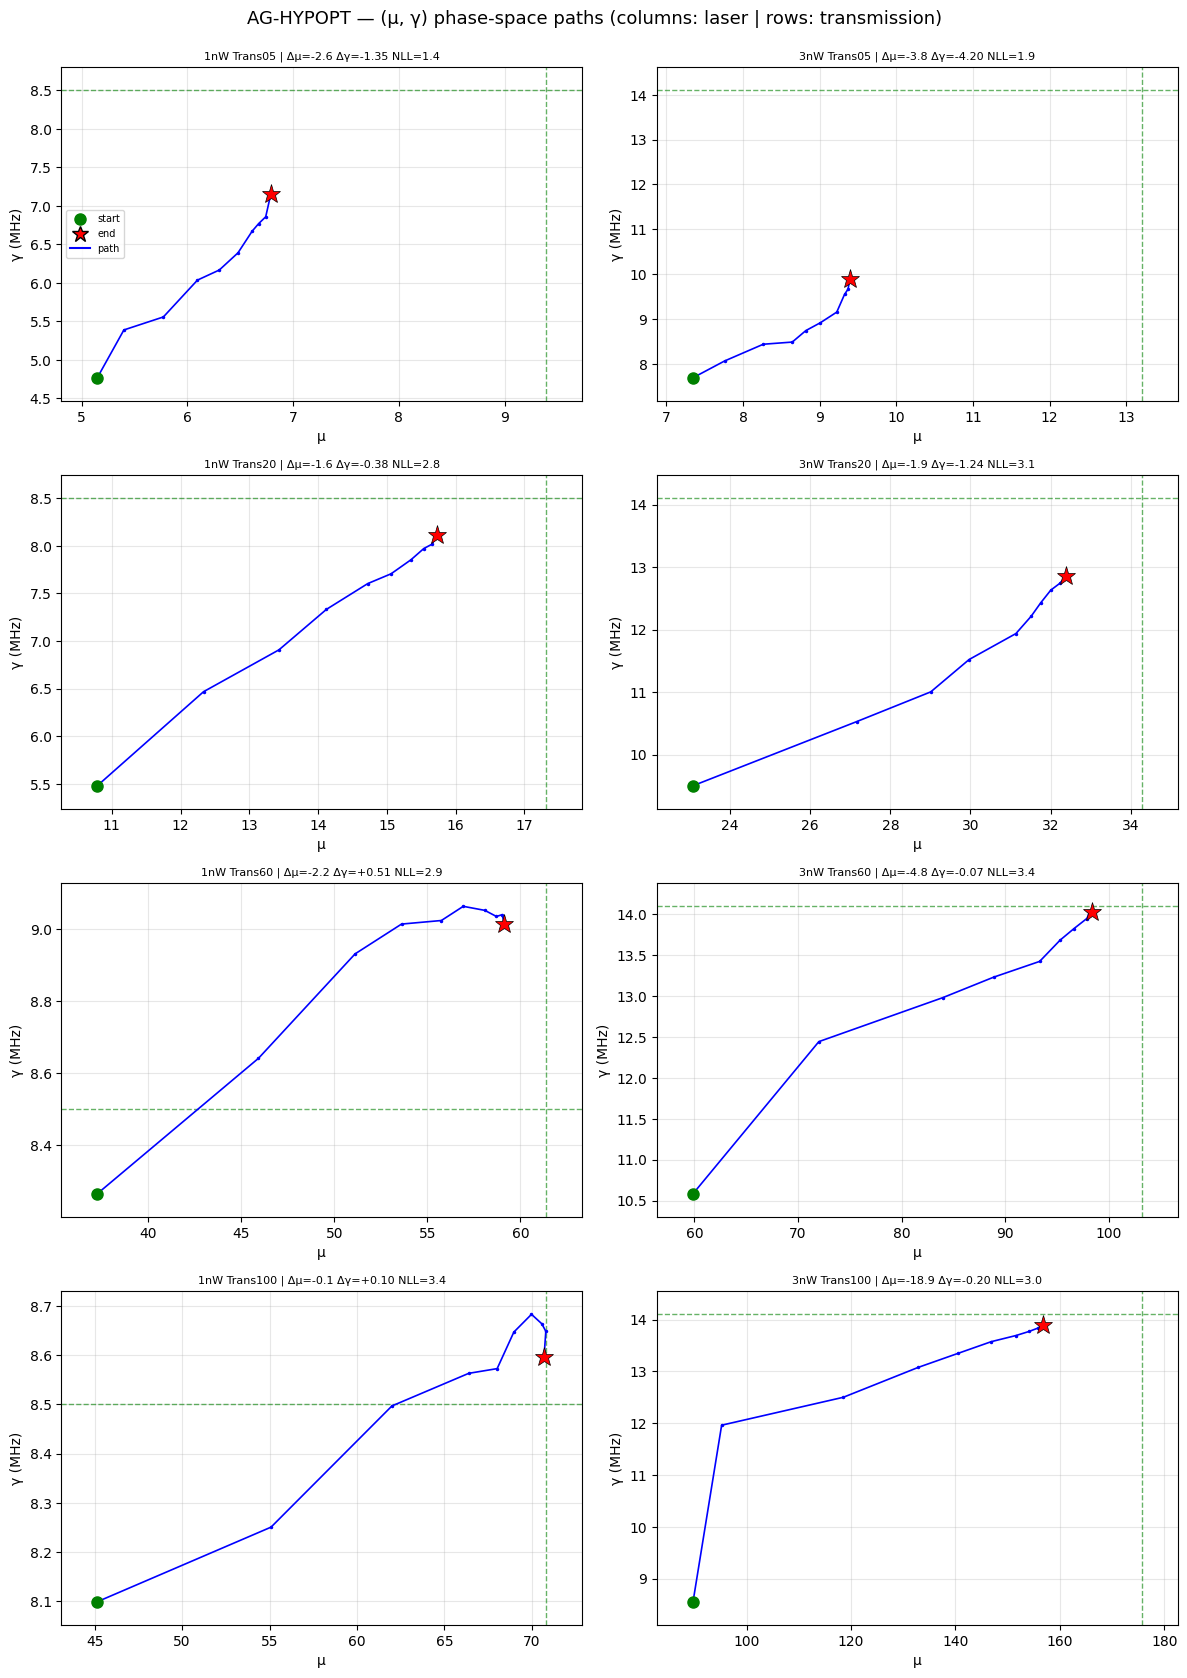

trial finished in 7.0 min
objective = 0.0196 ± 0.0080
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.79   -27.7 |     8.50    7.15   -15.9
1nW Trans20    17.32   15.73    -9.1 |     8.50    8.12    -4.5
1nW Trans60    61.37   59.13    -3.7 |     8.50    9.01    +6.0
1nW Trans100   70.82   70.70    -0.2 |     8.50    8.60    +1.1
3nW Trans05    13.20    9.40   -28.8 |    14.10    9.90   -29.8
3nW Trans20    34.28   32.39    -5.5 |    14.10   12.86    -8.8
3nW Trans60   103.20   98.40    -4.7 |    14.10   14.03    -0.5
3nW Trans100  175.71  156.80   -10.8 |    14.10   13.90    -1.4

μ: RMSE 7.186 (rel 15.3%, bias -4.495) | γ: RMSE 1.638 (rel 12.6%, bias -0.854)


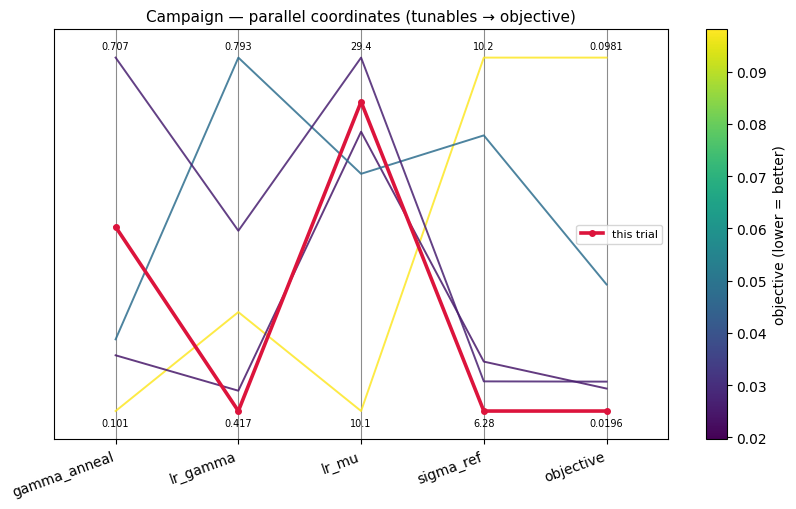

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 05 (sigma_ref 6.28, lr_mu 26.99, lr_gamma 0.42, gamma_anneal 0.42) ran 7.0 min and scored 0.0196 +/- 0.0080, the new best, beating trial 02 (0.0246) by ~20%. Both terms improved to their best-so-far values: mu rel RMSE 15.3% (bias -4.5, vs 17.5% in trial 02) and gamma rel RMSE 12.6% (bias -0.85, vs 13.7%). The config is a near-neighbour of trial 02 with lr_mu a touch higher (27.0 vs 25.4), sigma_ref a touch lower (6.28 vs 6.84), lr_gamma about the same (0.42 vs 0.44) and gamma_anneal at 0.42 (vs 0.20). Unlike trial 04 (lr_mu 29.4, gamma_anneal 0.71, gamma 15.1%), this moderate gamma_anneal of 0.42 did not hurt gamma, so trial 04's gamma regression was more likely its higher lr_gamma (0.61) and/or the 0.71 anneal than gamma_anneal per se. The high-transmission points are again excellent (1nW Trans100 -0.2%, Trans60 -4%, 3nW Trans60 -5%), and the weak spots remain the two Trans05 points (mu -28%/-29%, gamma -16% at 1nW and -30% at 3nW).

**Summary:** Trial 05 (sigma_ref 6.28, lr_mu 26.99, lr_gamma 0.42, gamma_anneal 0.42) scored 0.0196 +/- 0.0080, the new best: both mu (15.3%) and gamma (12.6%) rel RMSE improved, confirming a winning region near lr_mu ~27, low sigma_ref, low-to-moderate gamma_anneal.
**Key insight:** The optimum sits near lr_mu ~27, sigma_ref ~6.3, lr_gamma ~0.42, gamma_anneal ~0.2-0.4; moderate gamma_anneal is harmless, so trial 04's gamma loss came from its high lr_gamma / anneal combination.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 05 (sigma_ref 6.28, lr_mu 26.99, lr_gamma 0.42, gamma_anneal 0.42) scored 0.0196 +/- 0.0080, the new best: both mu (15.3%) and gamma (12.6%) rel RMSE improved, confirming a winning region near lr_mu ~27, low sigma_ref, low-to-moderate gamma_anneal.'
KEY_INSIGHT = 'The optimum sits near lr_mu ~27, sigma_ref ~6.3, lr_gamma ~0.42, gamma_anneal ~0.2-0.4; moderate gamma_anneal is harmless, so trial 04 gamma loss came from its high lr_gamma / anneal combination.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_05 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_06.ipynb. Open it and follow its cells from the top.
